In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import scipy
import statsmodels.api as sm
import statsmodels.formula.api as smf
import warnings 


In [2]:
df = pd.read_csv('/Users/jonathonmiles/Desktop/SIMPLILEARN ORGANIZED/INCREMENTAL CAPSTONES/Capstone Session 7/CC GENERAL.csv')

In [3]:
df.info

<bound method DataFrame.info of      CUST_ID      BALANCE  BALANCE_FREQUENCY  PURCHASES  ONEOFF_PURCHASES  \
0     C10001    40.900749           0.818182      95.40              0.00   
1     C10002  3202.467416           0.909091       0.00              0.00   
2     C10003  2495.148862           1.000000     773.17            773.17   
3     C10004  1666.670542           0.636364    1499.00           1499.00   
4     C10005   817.714335           1.000000      16.00             16.00   
...      ...          ...                ...        ...               ...   
8945  C19186    28.493517           1.000000     291.12              0.00   
8946  C19187    19.183215           1.000000     300.00              0.00   
8947  C19188    23.398673           0.833333     144.40              0.00   
8948  C19189    13.457564           0.833333       0.00              0.00   
8949  C19190   372.708075           0.666667    1093.25           1093.25   

      INSTALLMENTS_PURCHASES  CASH_ADVANCE 

In [4]:
df.head()

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [5]:
df.tail()

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
8945,C19186,28.493517,1.000000,291.12,0.00,291.12,0.000000,1.000000,0.000000,0.833333,0.000000,0,6,1000.0,325.594462,48.886365,0.50,6
8946,C19187,19.183215,1.000000,300.00,0.00,300.00,0.000000,1.000000,0.000000,0.833333,0.000000,0,6,1000.0,275.861322,NaN,0.00,6
8947,C19188,23.398673,0.833333,144.40,0.00,144.40,0.000000,0.833333,0.000000,0.666667,0.000000,0,5,1000.0,81.270775,82.418369,0.25,6
8948,C19189,13.457564,0.833333,0.00,0.00,0.00,36.558778,0.000000,0.000000,0.000000,0.166667,2,0,500.0,52.549959,55.755628,0.25,6
8949,C19190,372.708075,0.666667,1093.25,1093.25,0.00,127.040008,0.666667,0.666667,0.000000,0.333333,2,23,1200.0,63.165404,88.288956,0.00,6


In [6]:
df.describe()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
count,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8949.000000,8950.000000,8637.000000,8950.000000,8950.000000
mean,1564.474828,0.877271,1003.204834,592.437371,411.067645,978.871112,0.490351,0.202458,0.364437,0.135144,3.248827,14.709832,4494.449450,1733.143852,864.206542,0.153715,11.517318
std,2081.531879,0.236904,2136.634782,1659.887917,904.338115,2097.163877,0.401371,0.298336,0.397448,0.200121,6.824647,24.857649,3638.815725,2895.063757,2372.446607,0.292499,1.338331
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,50.000000,0.000000,0.019163,0.000000,6.000000
25%,128.281915,0.888889,39.635000,0.000000,0.000000,0.000000,0.083333,0.000000,0.000000,0.000000,0.000000,1.000000,1600.000000,383.276166,169.123707,0.000000,12.000000
50%,873.385231,1.000000,361.280000,38.000000,89.000000,0.000000,0.500000,0.083333,0.166667,0.000000,0.000000,7.000000,3000.000000,856.901546,312.343947,0.000000,12.000000
75%,2054.140036,1.000000,1110.130000,577.405000,468.637500,1113.821139,0.916667,0.300000,0.750000,0.222222,4.000000,17.000000,6500.000000,1901.134317,825.485459,0.142857,12.000000
max,19043.138560,1.000000,49039.570000,40761.250000,22500.000000,47137.211760,1.000000,1.000000,1.000000,1.500000,123.000000,358.000000,30000.000000,50721.483360,76406.207520,1.000000,12.000000


In [11]:
# Import all necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# 1. Load the dataset (assuming the file is in the same directory)
df = pd.read_csv('CC GENERAL.csv')

# 2. Check for null values
print("Initial missing values:")
print(df.isnull().sum())
print("\n" + "="*50 + "\n")

# 3. Handle null values by filling them with the mean
df['MINIMUM_PAYMENTS'] = df['MINIMUM_PAYMENTS'].fillna(df['MINIMUM_PAYMENTS'].mean())
df['CREDIT_LIMIT'] = df['CREDIT_LIMIT'].fillna(df['CREDIT_LIMIT'].mean())

# Verify that null values have been handled
print("Missing values after imputation:")
print(df.isnull().sum())
print("\n" + "="*50 + "\n")

# 4. Drop the 'CUST_ID' column as it's a unique identifier and not useful for clustering
df = df.drop('CUST_ID', axis=1)

# 5. Perform feature scaling using StandardScaler
scaler = StandardScaler()
scaled_features = scaler.fit_transform(df)

print("Shape of the scaled data:", scaled_features.shape)
print("\nScaled data sample:")
print(scaled_features[:5])

Initial missing values:
CUST_ID                               0
BALANCE                               0
BALANCE_FREQUENCY                     0
PURCHASES                             0
ONEOFF_PURCHASES                      0
INSTALLMENTS_PURCHASES                0
CASH_ADVANCE                          0
PURCHASES_FREQUENCY                   0
ONEOFF_PURCHASES_FREQUENCY            0
PURCHASES_INSTALLMENTS_FREQUENCY      0
CASH_ADVANCE_FREQUENCY                0
CASH_ADVANCE_TRX                      0
PURCHASES_TRX                         0
CREDIT_LIMIT                          1
PAYMENTS                              0
MINIMUM_PAYMENTS                    313
PRC_FULL_PAYMENT                      0
TENURE                                0
dtype: int64


Missing values after imputation:
CUST_ID                             0
BALANCE                             0
BALANCE_FREQUENCY                   0
PURCHASES                           0
ONEOFF_PURCHASES                    0
INSTALLMENTS_PURCH

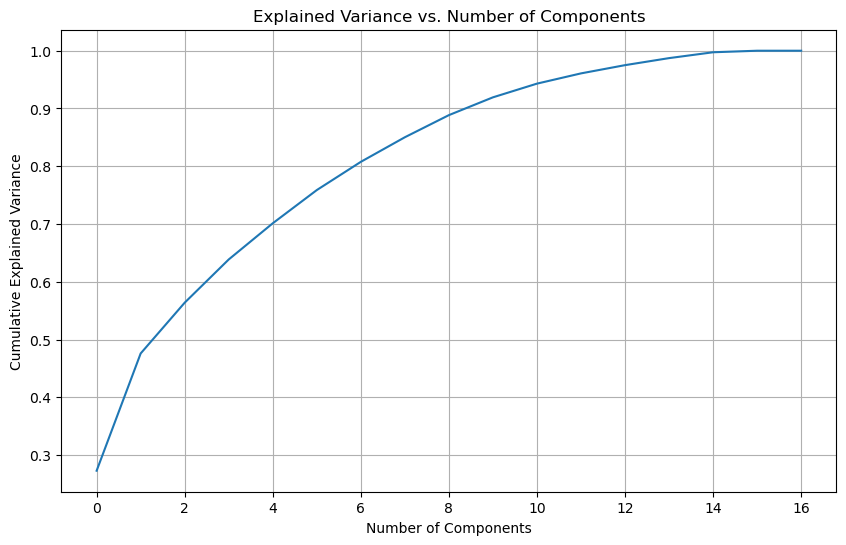

Number of components to cover 85% of variance: 8


In [10]:
# Perform PCA with all components
pca_all = PCA(n_components=scaled_features.shape[1])
pca_all.fit(scaled_features)

# Plot the cumulative explained variance
plt.figure(figsize=(10, 6))
plt.plot(np.cumsum(pca_all.explained_variance_ratio_))
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Explained Variance vs. Number of Components')
plt.grid(True)
plt.show()

# Find the number of components for 85% variance
cumulative_variance = np.cumsum(pca_all.explained_variance_ratio_)
n_components_85 = np.where(cumulative_variance >= 0.85)[0][0] + 1

print(f"Number of components to cover 85% of variance: {n_components_85}")

In [13]:
# --- Step 2.2: Perform PCA with 2 Components for Visualization ---
from sklearn.decomposition import PCA

# Assuming 'scaled_features' is available from Step 1
# Perform PCA with 2 principal components
pca_2 = PCA(n_components=2, random_state=42)
pca_transformed_data = pca_2.fit_transform(scaled_features)

print("Shape of PCA transformed data:", pca_transformed_data.shape)
print("\n" + "="*50 + "\n")

# Interpret PCA results by looking at the covariance matrix
print("PCA Covariance Matrix (using get_covariance()):")
print(pca_2.get_covariance())
print("\n" + "="*50 + "\n")

# Find the two original columns with the most covariance.
# The `components_` attribute shows the weight of each original feature in the principal components.
# We can find the features with the highest absolute values in each component.
most_correlated_component1 = df.columns[np.argmax(np.abs(pca_2.components_[0]))]
most_correlated_component2 = df.columns[np.argmax(np.abs(pca_2.components_[1]))]

print(f"The first principal component has the most covariance with '{most_correlated_component1}'.")
print(f"The second principal component has the most covariance with '{most_correlated_component2}'.")

Shape of PCA transformed data: (8950, 2)


PCA Covariance Matrix (using get_covariance()):
[[ 1.10168167  0.19978101  0.21571013  0.2142381   0.11634261  0.49750956
  -0.08876349  0.09979609 -0.09383525  0.46464733  0.46463958  0.13738239
   0.36208447  0.40610723  0.21742777 -0.1653374   0.02813804]
 [ 0.19978101  0.70102009  0.2152313   0.1916936   0.15666783  0.15251568
   0.08497215  0.13640882  0.06679424  0.11863595  0.13294592  0.18251498
   0.19183414  0.22535743  0.09159653 -0.0067231   0.03773544]
 [ 0.21571013  0.2152313   1.28439212  0.58428641  0.55876387  0.01263529
   0.51304705  0.48858602  0.43656186 -0.09754737 -0.03180541  0.64839724
   0.38049836  0.47361159  0.1200914   0.19773744  0.13442578]
 [ 0.2142381   0.1916936   0.58428641  1.09080689  0.46871348  0.04620268
   0.416293    0.40970632  0.35291501 -0.04693668  0.00722495  0.54407253
   0.33952735  0.41940682  0.11458121  0.15101292  0.11277242]
 [ 0.11634261  0.15666783  0.55876387  0.46871348  1.05397632 -0.

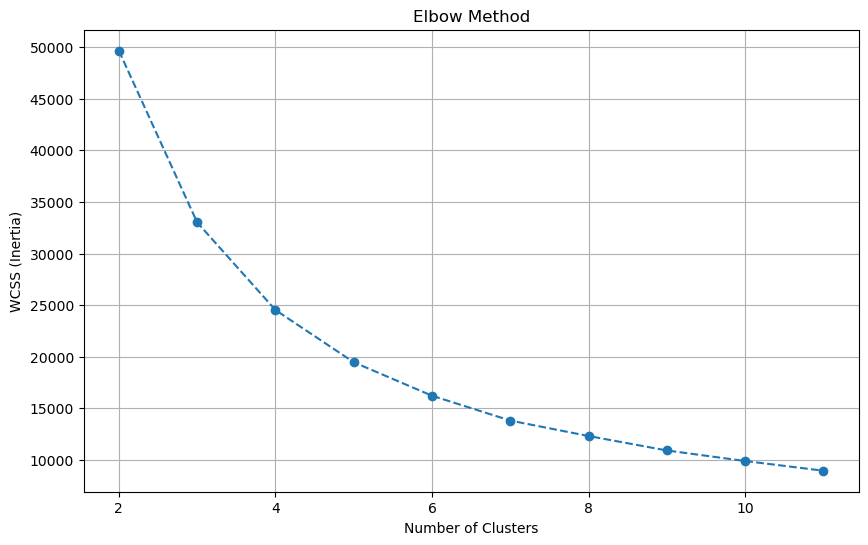

From the plot, the 'elbow' point indicates the optimal number of clusters.


In [14]:
# Assuming you have already run the previous steps and have 'pca_transformed_data' available

from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Find the ideal number of clusters using the Elbow Method
wcss = []  # Within-Cluster Sum of Squares
for i in range(2, 12):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(pca_transformed_data)
    wcss.append(kmeans.inertia_)

# Plot the Elbow Method
plt.figure(figsize=(10, 6))
plt.plot(range(2, 12), wcss, marker='o', linestyle='--')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS (Inertia)')
plt.grid(True)
plt.show()

print("From the plot, the 'elbow' point indicates the optimal number of clusters.")

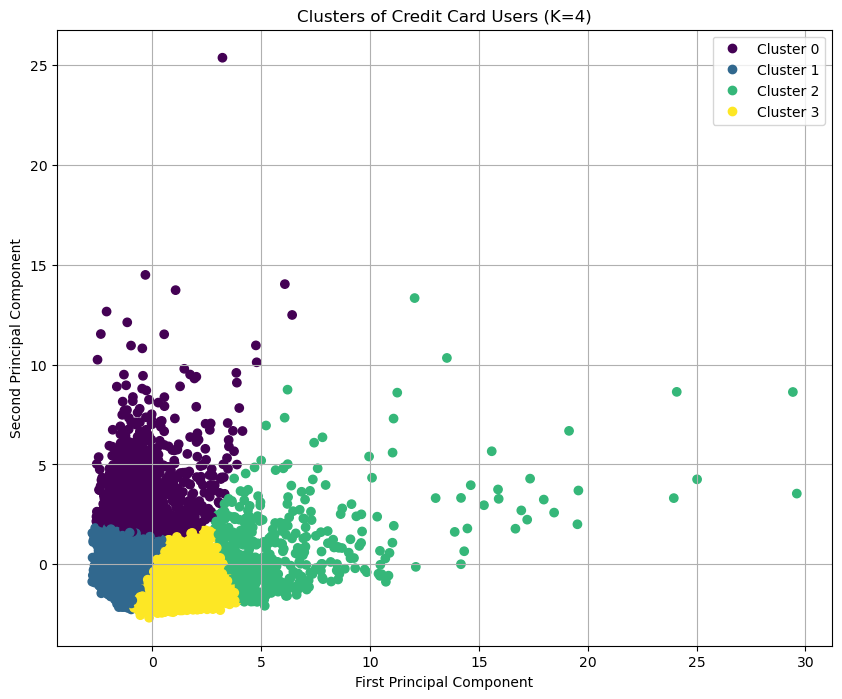

The scatter plot visualizes the credit card users grouped into their respective clusters.


In [15]:
# Based on the elbow plot, assume the ideal number of clusters is found
# For example, if the elbow is at 4, we use n_clusters=4
ideal_clusters = 4 # You should replace this with the value from your plot

# Perform K-Means Clustering with the ideal number of clusters
kmeans_final = KMeans(n_clusters=ideal_clusters, init='k-means++', random_state=42, n_init=10)
clusters = kmeans_final.fit_predict(pca_transformed_data)

# Visualize the clusters
plt.figure(figsize=(10, 8))
scatter = plt.scatter(pca_transformed_data[:, 0], pca_transformed_data[:, 1], c=clusters, cmap='viridis')
plt.xlabel('First Principal Component')
plt.ylabel('Second Principal Component')
plt.title(f'Clusters of Credit Card Users (K={ideal_clusters})')
plt.legend(handles=scatter.legend_elements()[0], labels=[f'Cluster {i}' for i in range(ideal_clusters)])
plt.grid(True)
plt.show()

print("The scatter plot visualizes the credit card users grouped into their respective clusters.")